TensorFlow Version: 2.20.0

Training RNN...
Epoch 1/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 30s 91ms/step - accuracy: 0.6662 - loss: 0.5925 - val_accuracy: 0.7680 - val_loss: 0.4909
Epoch 2/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 42s 94ms/step - accuracy: 0.8248 - loss: 0.3977 - val_accuracy: 0.8016 - val_loss: 0.4400
Epoch 3/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 39s 89ms/step - accuracy: 0.8730 - loss: 0.3093 - val_accuracy: 0.8210 - val_loss: 0.4627
RNN Accuracy: 0.8184

Training LSTM...
Epoch 1/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 78s 242ms/step - accuracy: 0.8110 - loss: 0.4109 - val_accuracy: 0.8714 - val_loss: 0.3168
Epoch 2/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 76s 243ms/step - accuracy: 0.9039 - loss: 0.2466 - val_accuracy: 0.8516 - val_loss: 0.3347
Epoch 3/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 76s 244ms/step - accuracy: 0.9322 - loss: 0.1852 - val_accuracy: 0.8650 - val_loss: 0.3192
LSTM Accuracy: 0.8626

Training GRU...
Epoch 1/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 91s 283ms/step - accuracy: 0.7886 - loss: 0.4362 - val_accurac

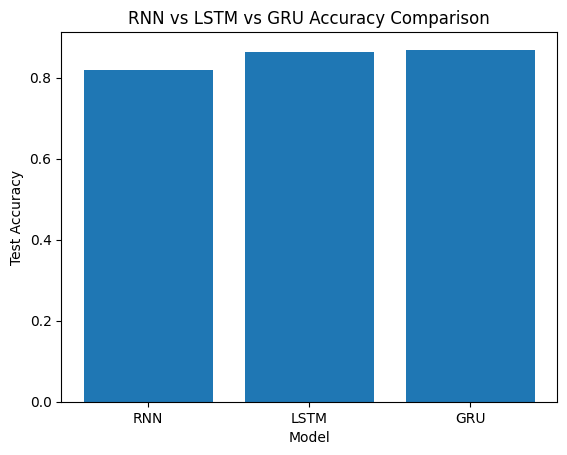

In [2]:
# ================================
# RNN vs LSTM vs GRU
# ================================

import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
import matplotlib.pyplot as plt

print("TensorFlow Version:", tf.__version__)

# -------------------------------
# LOAD DATA
# -------------------------------
vocab_size = 10000
max_len = 200

(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=vocab_size)

x_train = pad_sequences(x_train, maxlen=max_len)
x_test = pad_sequences(x_test, maxlen=max_len)

# -------------------------------
# MODEL FUNCTION
# -------------------------------
def create_model(model_type):
    model = Sequential()
    model.add(Embedding(vocab_size, 128, input_length=max_len))

    if model_type == "RNN":
        model.add(SimpleRNN(64))
    elif model_type == "LSTM":
        model.add(LSTM(64))
    elif model_type == "GRU":
        model.add(GRU(64))

    model.add(Dense(1, activation='sigmoid'))

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

# -------------------------------
# TRAIN + STORE HISTORY
# -------------------------------
model_types = ["RNN", "LSTM", "GRU"]
results = {}
histories = {}

for m in model_types:
    print(f"\nTraining {m}...")

    model = create_model(m)

    history = model.fit(
        x_train, y_train,
        epochs=3,
        batch_size=64,
        validation_split=0.2,
        verbose=1
    )

    loss, acc = model.evaluate(x_test, y_test, verbose=0)

    results[m] = acc
    histories[m] = history

    print(f"{m} Accuracy: {acc:.4f}")

# -------------------------------
# BAR GRAPH (FINAL COMPARISON)
# -------------------------------
plt.figure()
plt.bar(results.keys(), results.values())
plt.xlabel("Model")
plt.ylabel("Test Accuracy")
plt.title("RNN vs LSTM vs GRU Accuracy Comparison")
plt.show()




